In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def find_file(filename):
    """Search common project locations for a file."""
    possible_paths = [
        Path(filename),
        Path('notebooks') / filename,
        Path('..') / filename,
        Path('../notebooks') / filename,
    ]
    for path in possible_paths:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}. Put it in notebooks/ or project root.")

In [2]:
# Load files
model = load_model(find_file('LSTM-Stock-Market.keras'))
scaler = joblib.load(find_file('stock-scaler.sav'))

data = np.load(find_file('data.npy'))
target = np.load(find_file('target.npy'))

print('Data shape:', data.shape)
print('Target shape:', target.shape)

Data shape: (1209, 50, 1)
Target shape: (1209, 1)


In [3]:

data_scaled = scaler.transform(data.reshape(-1, 1)).reshape(data.shape)

train_data = data_scaled[:1000]
train_target = target[:1000]

test_data = data_scaled[1000:]
test_target = target[1000:]

print('Train data:', train_data.shape)
print('Test data:', test_data.shape)
print('Train target:', train_target.shape)
print('Test target:', test_target.shape)

Train data: (1000, 50, 1)
Test data: (209, 50, 1)
Train target: (1000, 1)
Test target: (209, 1)


In [4]:

predictions = model.predict(test_data).reshape(-1)
actual = test_target.reshape(-1)

print('Predictions shape:', predictions.shape)
print('Actual shape:', actual.shape)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
Predictions shape: (209,)
Actual shape: (209,)


In [5]:

mae = mean_absolute_error(actual, predictions)
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)

nonzero_mask = actual != 0
mape = np.mean(np.abs((actual[nonzero_mask] - predictions[nonzero_mask]) / actual[nonzero_mask])) * 100

r2 = r2_score(actual, predictions)

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R² Score'],
    'Value': [mae, mse, rmse, mape, r2]
})

metrics_df

,Metric,Value
0,MAE,0.041783
1,MSE,0.002264
2,RMSE,0.047577
3,MAPE (%),4.957113
4,R² Score,0.692208


In [6]:

results_df = pd.DataFrame({
    'Actual_Open_Price': actual,
    'Predicted_Open_Price': predictions,
    'Error': actual - predictions,
    'Absolute_Error': np.abs(actual - predictions)
})

results_df.to_csv('lstm_prediction_results.csv', index=False)
metrics_df.to_csv('lstm_evaluation_metrics.csv', index=False)

print('Saved: lstm_prediction_results.csv')
print('Saved: lstm_evaluation_metrics.csv')
results_df.head()

Saved: lstm_prediction_results.csv
Saved: lstm_evaluation_metrics.csv


,Actual_Open_Price,Predicted_Open_Price,Error,Absolute_Error
0,0.706081,0.687781,0.018301,0.018301
1,0.695270,0.686366,0.008904,0.008904
2,0.697771,0.683237,0.014534,0.014534
3,0.694302,0.678895,0.015407,0.015407
4,0.693737,0.674018,0.019719,0.019719


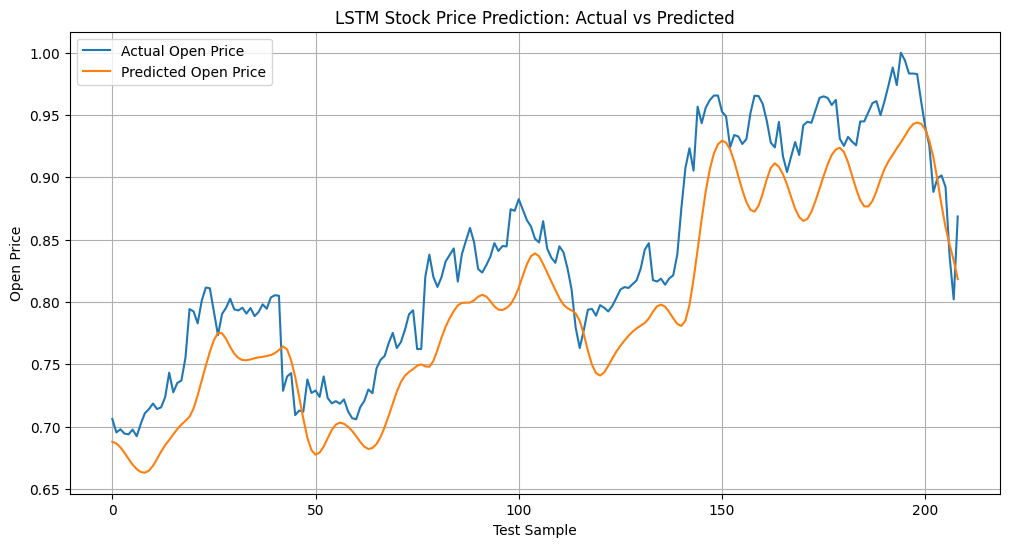

In [7]:

plt.figure(figsize=(12, 6))
plt.plot(actual, label='Actual Open Price')
plt.plot(predictions, label='Predicted Open Price')
plt.title('LSTM Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Test Sample')
plt.ylabel('Open Price')
plt.legend()
plt.grid(True)
plt.show()

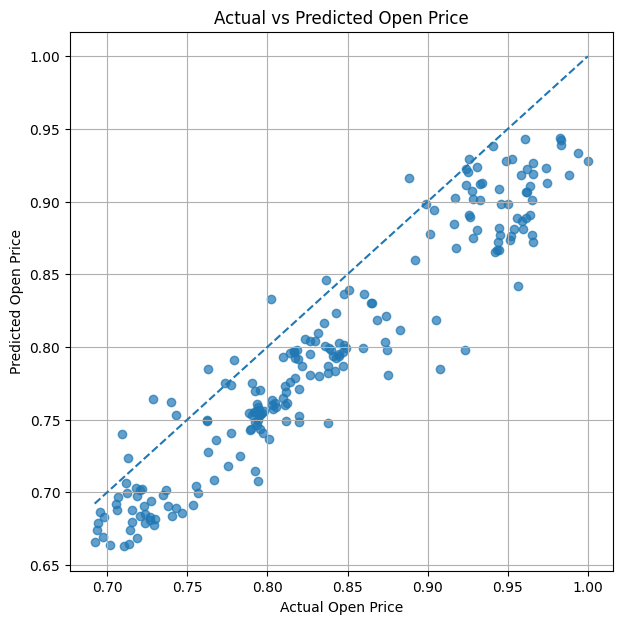

In [8]:

plt.figure(figsize=(7, 7))
plt.scatter(actual, predictions, alpha=0.7)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], linestyle='--')
plt.title('Actual vs Predicted Open Price')
plt.xlabel('Actual Open Price')
plt.ylabel('Predicted Open Price')
plt.grid(True)
plt.show()

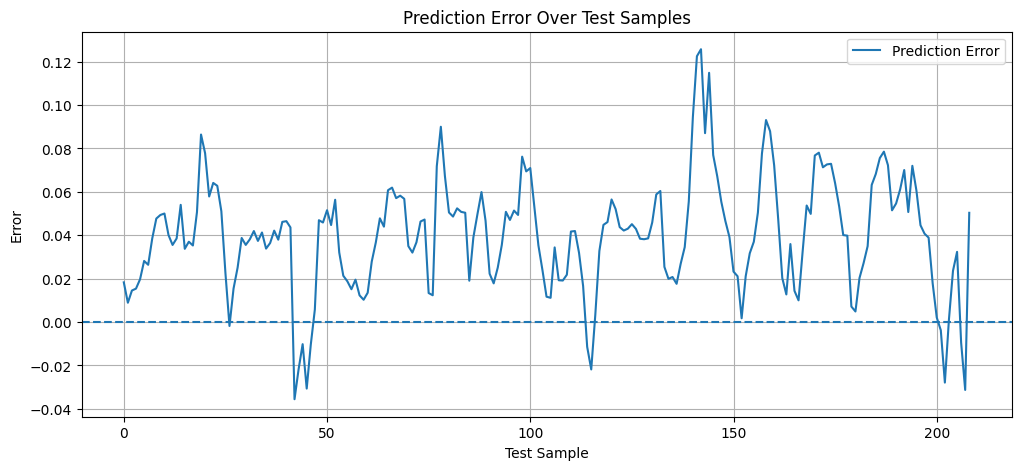

In [9]:

plt.figure(figsize=(12, 5))
plt.plot(actual - predictions, label='Prediction Error')
plt.axhline(0, linestyle='--')
plt.title('Prediction Error Over Test Samples')
plt.xlabel('Test Sample')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()